In [65]:
from pathlib import Path
import os 
from dotenv import load_dotenv
import evaluate
from datasets import load_dataset
from transformers import (
AutoModelForSequenceClassification,
DataCollatorWithPadding
)
import torch 
from torch.utils.data import DataLoader


In [66]:
load_dotenv()
val_path  = Path(os.getenv("VALIDATION_PATH"))
FORMAT = os.getenv("FORMAT")
result_path = Path("../results")

In [67]:
raw_data = load_dataset(
        FORMAT,
        data_files={"val":str(val_path)},
        columns=["text","label","lang"]
    ).shuffle(seed=42)
    langs= raw_data["val"]["lang"]

IndentationError: unexpected indent (2124673821.py, line 6)

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[1]  # adjust if needed
sys.path.append(str(PROJECT_ROOT))

In [ ]:
from scripts.tokenizer import Tokenizer
melectra_tokenizer = Tokenizer(r"C:\Users\amine\Desktop\UWSP\workspace\ai-text-detection\models\electra")
electra = AutoModelForSequenceClassification.from_pretrained(r"C:\Users\amine\Desktop\UWSP\workspace\ai-text-detection\models\electra")

Loading weights: 100%|██████████| 203/203 [00:00<00:00, 4177.29it/s]


In [ ]:
electra_data = raw_data["val"].map(
        melectra_tokenizer.tokenize,
        remove_columns=raw_data["val"].column_names
        )

electra_data_collator = DataCollatorWithPadding(melectra_tokenizer.tokenizer)
electra_data.set_format("torch")
electra_data_loader = DataLoader(
        electra_data,
        batch_size=16,
        collate_fn=electra_data_collator,
        shuffle=False
    )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Map: 100%|██████████| 100000/100000 [02:00<00:00, 826.86 examples/s]


In [ ]:
from tqdm import tqdm 
electra_y_true = []
electra_y_probs = []

electra.to(device)
electra.eval()

for batch in tqdm(electra_data_loader, desc="Eval", unit="batch"):

    inputs = {
        "input_ids": batch["input_ids"].to(device),
        "attention_mask": batch["attention_mask"].to(device)
    }

    labels = batch["labels"]

    with torch.inference_mode():
        outputs = electra(**inputs)

    logits = outputs.logits

    probs = torch.softmax(logits, dim=1)

    ai_probs = probs[:, 1]  # probability of AI class

    electra_y_probs.extend(ai_probs.cpu().numpy())
    electra_y_true.extend(labels.cpu().numpy())

Eval: 100%|██████████| 6250/6250 [09:18<00:00, 11.19batch/s]


NameError: name 'np' is not defined

In [ ]:
import numpy as np 
# convert to numpy
electra_y_true = np.array(electra_y_true)
electra_y_probs = np.array(electra_y_probs)
electra_y_pred = (electra_y_probs >= 0.5).astype(int)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(
    electra_y_true,
    electra_y_pred,
    target_names=["Human", "AI"]
))
print(confusion_matrix(electra_y_true, electra_y_pred))

              precision    recall  f1-score   support

       Human       0.98      0.82      0.90     80000
          AI       0.57      0.95      0.71     20000

    accuracy                           0.85    100000
   macro avg       0.78      0.88      0.80    100000
weighted avg       0.90      0.85      0.86    100000

[[65749 14251]
 [ 1069 18931]]


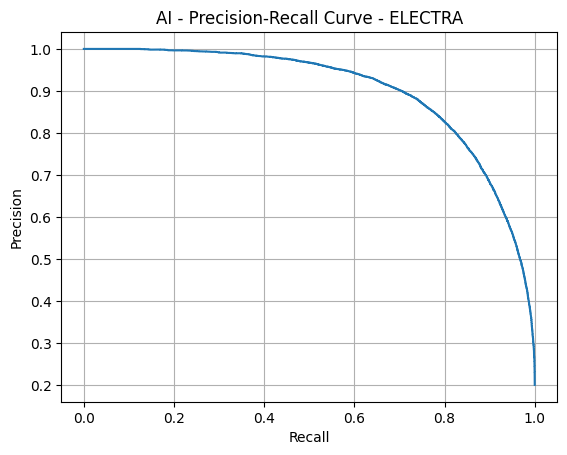

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
precision, recall, threhsolds = precision_recall_curve(
    electra_y_true,
    electra_y_probs
)

plt.figure()
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("AI - Precision-Recall Curve - ELECTRA")
plt.grid(True)
plt.show()

In [ ]:
threshold_index = (recall < 0.8).argmax()
electra_threshold = threhsolds[threshold_index]

In [ ]:
electra_y_pred = (electra_y_probs >= electra_threshold).astype(int)

In [ ]:
print(classification_report(
    electra_y_true,
    electra_y_pred,
    target_names=["Human", "AI"]
))

              precision    recall  f1-score   support

       Human       0.95      0.96      0.95     80000
          AI       0.83      0.80      0.81     20000

    accuracy                           0.93    100000
   macro avg       0.89      0.88      0.88    100000
weighted avg       0.93      0.93      0.93    100000



In [ ]:
best_threhsolds = {
    "electra":electra_threshold
}

In [ ]:
from scripts.tokenizer import Tokenizer
mbert_tokenizer = Tokenizer(r"C:\Users\amine\Desktop\UWSP\workspace\ai-text-detection\models\mbert_dist")
mbert= AutoModelForSequenceClassification.from_pretrained(r"C:\Users\amine\Desktop\UWSP\workspace\ai-text-detection\models\mbert_dist")

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 15184.59it/s]


In [ ]:
mbert_data = raw_data["val"].map(
        mbert_tokenizer.tokenize,
        remove_columns=raw_data["val"].column_names
        )

mbert_data_collator = DataCollatorWithPadding(mbert_tokenizer.tokenizer)
mbert_data.set_format("torch")
mbert_data_loader = DataLoader(
        mbert_data,
        batch_size=16,
        collate_fn=mbert_data_collator,
        shuffle=True
    )

Map: 100%|██████████| 100000/100000 [01:39<00:00, 1004.76 examples/s]


In [ ]:
from tqdm import tqdm 
mbert_y_true = []
mbert_y_probs = []

mbert.to(device)
mbert.eval()

for batch in tqdm(mbert_data_loader, desc="Eval", unit="batch"):

    inputs = {
        "input_ids": batch["input_ids"].to(device),
        "attention_mask": batch["attention_mask"].to(device)
    }

    labels = batch["labels"]

    with torch.inference_mode():
        outputs = mbert(**inputs)

    logits = outputs.logits

    probs = torch.softmax(logits, dim=1)

    ai_probs = probs[:, 1]  # probability of AI class

    mbert_y_probs.extend(ai_probs.cpu().numpy())
    mbert_y_true.extend(labels.cpu().numpy())
# convert to numpy
mbert_y_true = np.array(mbert_y_true)
mbert_y_probs = np.array(mbert_y_probs)
mbert_y_pred = (mbert_y_probs >= 0.5).astype(int)

Eval: 100%|██████████| 6250/6250 [25:17<00:00,  4.12batch/s]


In [68]:
print(classification_report(
    mbert_y_true,
    mbert_y_pred,
    target_names=["Human", "AI"]
))

              precision    recall  f1-score   support

       Human       0.99      0.90      0.94     80000
          AI       0.70      0.95      0.81     20000

    accuracy                           0.91    100000
   macro avg       0.84      0.92      0.87    100000
weighted avg       0.93      0.91      0.91    100000



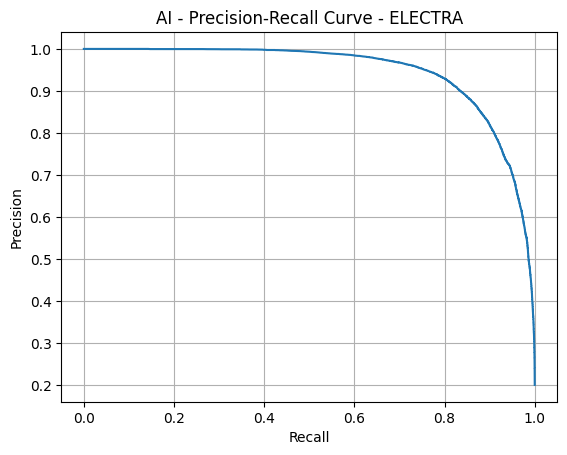

In [ ]:
precision, recall, threhsolds = precision_recall_curve(
    mbert_y_true,
    mbert_y_probs
)
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("AI - Precision-Recall Curve - MBERT")
plt.grid(True)
plt.show()

In [69]:
threshold_index = (recall <= 0.8).argmax()
mbert_threshold = threhsolds[threshold_index]
mbert_y_pred = (mbert_y_probs >= mbert_threshold).astype(int)

In [70]:
print(classification_report(
    mbert_y_true,
    mbert_y_pred,
    target_names=["Human", "AI"]
))

              precision    recall  f1-score   support

       Human       0.95      0.98      0.97     80000
          AI       0.93      0.80      0.86     20000

    accuracy                           0.95    100000
   macro avg       0.94      0.89      0.91    100000
weighted avg       0.95      0.95      0.95    100000



In [71]:
best_threhsolds["mbert"]=mbert_threshold

In [78]:
from scripts.tokenizer import Tokenizer
xlm_tokenizer = Tokenizer(r"C:\Users\amine\Desktop\UWSP\workspace\ai-text-detection\models\xlm_r\checkpoint-62188")
xlm= AutoModelForSequenceClassification.from_pretrained(r"C:\Users\amine\Desktop\UWSP\workspace\ai-text-detection\models\xlm_r\checkpoint-62188")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 2203.99it/s]
XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 0it [00:00, 

In [79]:
xlm_data = raw_data["val"].map(
        xlm_tokenizer.tokenize,
        remove_columns=raw_data["val"].column_names
        )

xlm_data_collator = DataCollatorWithPadding(xlm_tokenizer.tokenizer)
xlm_data.set_format("torch")
xlm_data_loader = DataLoader(
        xlm_data,
        batch_size=16,
        collate_fn=xlm_data_collator,
        shuffle=True
    )

Map: 100%|██████████| 100000/100000 [02:11<00:00, 763.27 examples/s]


In [80]:
from tqdm import tqdm 
xlm_y_true = []
xlm_y_probs = []

xlm.to(device)
xlm.eval()

for batch in tqdm(xlm_data_loader, desc="Eval", unit="batch"):

    inputs = {
        "input_ids": batch["input_ids"].to(device),
        "attention_mask": batch["attention_mask"].to(device)
    }

    labels = batch["labels"]

    with torch.inference_mode():
        outputs = xlm(**inputs)

    logits = outputs.logits

    probs = torch.softmax(logits, dim=1)

    ai_probs = probs[:, 1]  # probability of AI class

    xlm_y_probs.extend(ai_probs.cpu().numpy())
    xlm_y_true.extend(labels.cpu().numpy())
# convert to numpy
xlm_y_true = np.array(xlm_y_true)
xlm_y_probs = np.array(xlm_y_probs)
xlm_y_pred = (xlm_y_probs >= 0.5).astype(int)

Eval: 100%|██████████| 6250/6250 [47:18<00:00,  2.20batch/s]


In [83]:
print(classification_report(
    xlm_y_true,
    xlm_y_pred,
    target_names=["Human", "AI"]
))

              precision    recall  f1-score   support

       Human       0.00      0.00      0.00     80000
          AI       0.20      1.00      0.33     20000

    accuracy                           0.20    100000
   macro avg       0.10      0.50      0.17    100000
weighted avg       0.04      0.20      0.07    100000



c:\Users\amine\Desktop\UWSP\dl-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\amine\Desktop\UWSP\dl-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\amine\Desktop\UWSP\dl-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

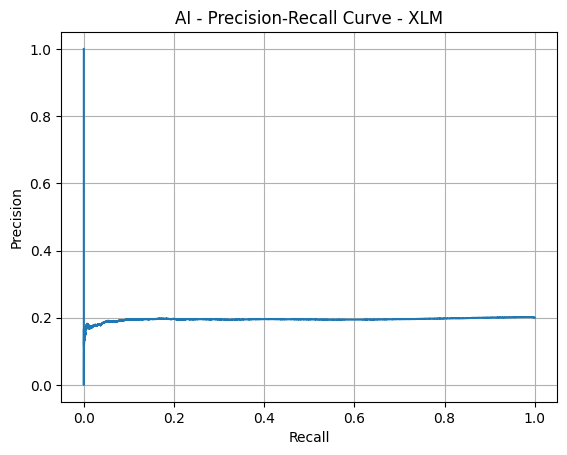

In [84]:
precision, recall, threhsolds = precision_recall_curve(
    xlm_y_true,
    xlm_y_probs
)
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("AI - Precision-Recall Curve - XLM")
plt.grid(True)
plt.show()

this one will be Ignored 

In [88]:
for k,v in best_threhsolds.items():
    best_threhsolds[k] = float(v)

In [89]:
import json
with open(result_path / "threhsolds.json","w") as f:
    json.dump(best_threhsolds,f)